In [61]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt

print("import libraries successfully")

import libraries successfully


In [62]:
# Define a list of all available phantom series folders
phantom_series_list = [
    "./dataset/FANTOCCIO/S72990/S1000", # Index 0
    "./dataset/FANTOCCIO/S72990/S2010", # Index 1
    "./dataset/FANTOCCIO/S72990/S3010", # Index 2
    "./dataset/FANTOCCIO/S72990/S5010"  # Index 3
]

In [63]:
# Print FANTOCCIO DICOM series summary
print("=== SUMMARY OF ALL PHANTOM ACQUISITIONS ===\n")

# Loop through EVERY folder in the list
for phantom_folder in phantom_series_list:
    print(f"Analyzing folder: {phantom_folder}")
    
    if not os.path.exists(phantom_folder):
        print("  -> Error: Folder does not exist.\n")
        continue
        
    files_in_folder = [f for f in os.listdir(phantom_folder) if os.path.isfile(os.path.join(phantom_folder, f))]
    
    valid_slices_count = 0
    first_ds = None
    
    # Scan all files in the folder to count valid DICOM slices and read the first one for metadata
    for file_name in files_in_folder:
        file_path = os.path.join(phantom_folder, file_name)
        try:
            # Count slices
            temp_ds = pydicom.dcmread(file_path, stop_before_pixels=True)
            
            # Check if it's an image
            if hasattr(temp_ds, 'Rows') and hasattr(temp_ds, 'Columns'):
                valid_slices_count += 1
                
                # Read ONLY the first valid slice
                if first_ds is None:
                    first_ds = pydicom.dcmread(file_path)
        except Exception:
            pass 
            
    # Print tsummary for this folder
    if first_ds is not None:
        rows = first_ds.get('Rows', 'N/A')
        cols = first_ds.get('Columns', 'N/A')
        thickness = first_ds.get('SliceThickness', 'N/A')
        spacing = first_ds.get('PixelSpacing', ['N/A', 'N/A'])
        
        # Calculate pixel value range (min and max raw values)
        pixel_data = first_ds.pixel_array
        min_val = np.min(pixel_data)
        max_val = np.max(pixel_data)
        
        print(f"  - Total slices: {valid_slices_count}")
        print(f"  - Slice dimensions (Matrix): {rows} x {cols}")
        print(f"  - Slice thickness (Z): {thickness} mm")
        print(f"  - Pixel dimensions (X, Y): {spacing[0]} x {spacing[1]} mm")
        print(f"  - Pixel value range: Min {min_val} to Max {max_val}")
    else:
        print("  -> Error: No valid DICOM images found in this folder.")
        
    print("-" * 60)

=== SUMMARY OF ALL PHANTOM ACQUISITIONS ===

Analyzing folder: ./dataset/FANTOCCIO/S72990/S1000
  - Total slices: 2
  - Slice dimensions (Matrix): 225 x 512
  - Slice thickness (Z): 0.625 mm
  - Pixel dimensions (X, Y): 0.9765625 x 0.9765625 mm
  - Pixel value range: Min 0 to Max 1102
------------------------------------------------------------
Analyzing folder: ./dataset/FANTOCCIO/S72990/S2010
  - Total slices: 571
  - Slice dimensions (Matrix): 512 x 512
  - Slice thickness (Z): 0.67 mm
  - Pixel dimensions (X, Y): 0.37890625 x 0.37890625 mm
  - Pixel value range: Min 0 to Max 3728
------------------------------------------------------------
Analyzing folder: ./dataset/FANTOCCIO/S72990/S3010
  - Total slices: 577
  - Slice dimensions (Matrix): 512 x 512
  - Slice thickness (Z): 0.67 mm
  - Pixel dimensions (X, Y): 0.333984375 x 0.333984375 mm
  - Pixel value range: Min 3 to Max 2414
------------------------------------------------------------
Analyzing folder: ./dataset/FANTOCCIO/S72

In [75]:
# --- FUNCTION TO PLOT A SINGLE DICOM IMAGE ---
def plot_dicom_image(file_path):
    
    if not os.path.exists(file_path):
        print(f"Error: Cannot find the file at path:\n{file_path}")
        return

    try:
        # 1. Read the file
        dataset = pydicom.dcmread(file_path)
        image = dataset.pixel_array
        
        # Extract dimensions and calculate total pixels
        height, width = image.shape
        total_pixels = image.size
        min_val = image.min()
        max_val = image.max()
        
        # Print information to the console
        print("--- IMAGE INFORMATION ---")
        print(f"Dimensions (Height x Width): {height} x {width}")
        print(f"Total number of pixels: {total_pixels}")
        print(f"Pixel value range: Min {min_val} to Max {max_val}")
        print("-------------------------")
        
        # 2. Plot  image
        plt.figure(figsize=(8, 8))
        
        im = plt.imshow(image, cmap='gray')
        plt.colorbar(im, fraction=0.046, pad=0.04, label='Pixel Intensity')
        
        # Use the file name and info as the title
        file_name = os.path.basename(file_path)
        plt.title(f"{file_name}", fontsize=14, fontweight='bold')
                  
        # plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error reading file: {e}")

--- IMAGE INFORMATION ---
Dimensions (Height x Width): 225 x 512
Total number of pixels: 115200
Pixel value range: Min 0 to Max 1102
-------------------------


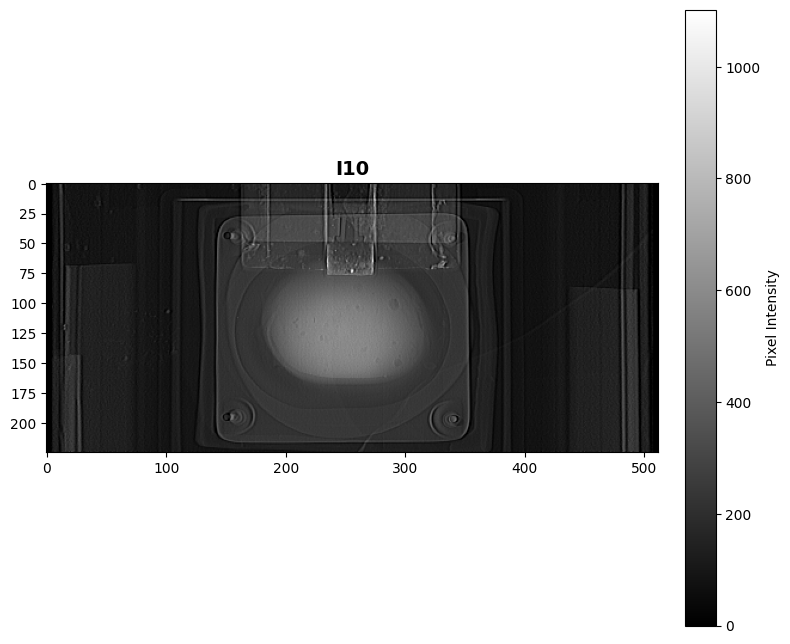

In [76]:
# Plot single DICOM image from the selected folder
file_path = "./dataset/FANTOCCIO/S72990/S1000/I10"

plot_dicom_image(file_path)

In [66]:
# Select the folder to analyze
selected_index = 0
phantom_folder = phantom_series_list[selected_index]
print(f"Searching in folder: {phantom_folder}")

Searching in folder: ./dataset/FANTOCCIO/S72990/S1000


In [67]:
# Find first valid DICOM image in the selected folder to be analyzed in detail
files_in_folder = [f for f in os.listdir(phantom_folder) if os.path.isfile(os.path.join(phantom_folder, f))]

# Sort files to ensure consistent order
files_in_folder.sort()

# Find the first image file
valid_image_found = False

for file_name in files_in_folder:
    file_path = os.path.join(phantom_folder, file_name)
    try:
        temp_ds = pydicom.dcmread(file_path)
        
        # Check if an image
        if hasattr(temp_ds, 'PixelData'):
            ds = temp_ds # Save the valid dataset
            print(f"Success! Found a valid image file: {file_name}")
            valid_image_found = True
            break
            
    except Exception:
        pass

if not valid_image_found:
    print("Error: No valid DICOM image found!")

Success! Found a valid image file: I10


In [68]:
# --- COMPUTE HOUNSFIELD UNITS (HU) AND NORMALIZATION ---

# Extract the Rescale Intercept and Slope for HU conversion
intercept = ds.get('RescaleIntercept', 0)
slope = ds.get('RescaleSlope', 1)

print(f"Rescale Intercept: {intercept}")
print(f"Rescale Slope: {slope}")

# 1. Extract the raw pixel array
raw_pixels = ds.pixel_array

# 2. Calculate Hounsfield Units (HU)
hu_pixels = (raw_pixels.astype(np.float64) * slope) + intercept

# 3. Min-Max Normalization (0 to 1)
min_hu = np.min(hu_pixels)
max_hu = np.max(hu_pixels)

# Apply (x - min) / (max - min)
if max_hu - min_hu != 0:
    normalized_pixels = (hu_pixels - min_hu) / (max_hu - min_hu)
else:
    normalized_pixels = np.zeros_like(hu_pixels)

print("\nExtraction raw data, HU conversion, and Normalization [0, 1] completed successfully.")

Rescale Intercept: -1024
Rescale Slope: 1

Extraction raw data, HU conversion, and Normalization [0, 1] completed successfully.


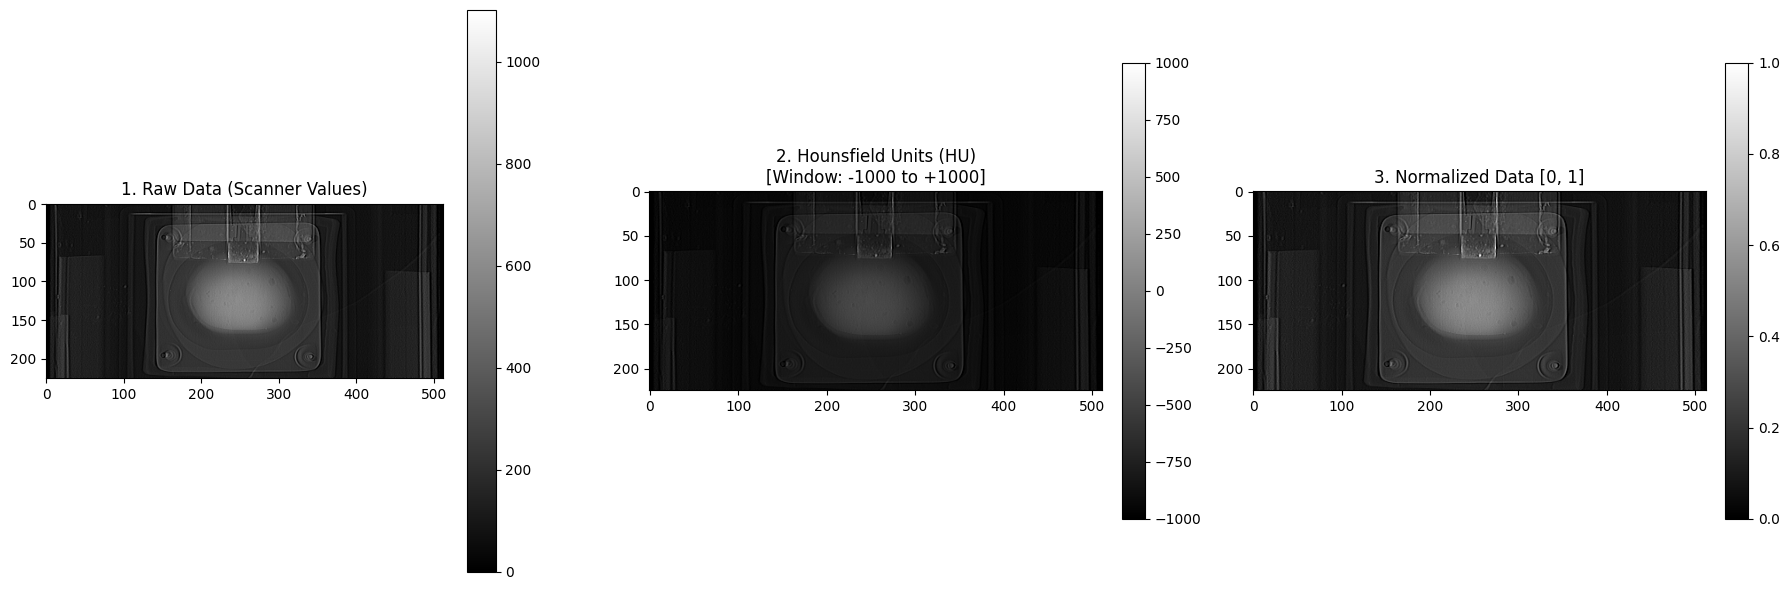

=== MIN/MAX VALUES CHECK ===
1. Raw Pixels        -> Min: 0.00, Max: 1102.00
2. HU Pixels         -> Min: -1024.00, Max: 78.00
3. Normalized Pixels -> Min: 0.00, Max: 1.00


In [ ]:
# Plot the three images side by side for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Raw Data
im1 = axes[0].imshow(raw_pixels, cmap='gray')
axes[0].set_title("1. Raw Data (Scanner Values)")
# axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2: Hounsfield Units (HU)
# vmin=-1000 and vmax=1000 apply the standard medical windowing
im2 = axes[1].imshow(hu_pixels, cmap='gray', vmin=-1000, vmax=1000)
axes[1].set_title("2. Hounsfield Units (HU)\n[Window: -1000 to +1000]")
# axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Plot 3: Normalized Data [0, 1]
# We set vmin=0 and vmax=1 because the data is perfectly scaled
im3 = axes[2].imshow(normalized_pixels, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("3. Normalized Data [0, 1]")
# axes[2].axis('off')
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Check Min and Max values to validate our mathematical transformations
print("=== MIN/MAX VALUES CHECK ===")
print(f"1. Raw Pixels        -> Min: {np.min(raw_pixels):.2f}, Max: {np.max(raw_pixels):.2f}")
print(f"2. HU Pixels         -> Min: {np.min(hu_pixels):.2f}, Max: {np.max(hu_pixels):.2f}")
print(f"3. Normalized Pixels -> Min: {np.min(normalized_pixels):.2f}, Max: {np.max(normalized_pixels):.2f}")